# Mall Customer Segmentation - Practical 1

## Step 0: Initialization

This section prepares everything required for the full notebook to run from top to bottom.

It includes:

- Importing all required libraries
- Hiding warning messages
- Setting plot style
- Loading the dataset
- Renaming columns
- Dropping unnecessary columns
- Encoding Gender
- Creating scaled features
- Creating the 2-feature clustering dataset
- Setting common constants such as `RANDOM_STATE`


In [1]:
# ==========================
# Step 0: Initialization
# ==========================

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

RANDOM_STATE = 42
DATA_PATHS = [
    Path('Mall_Customers.csv'),
    Path(r'D:\Unsupervised learning\PR1\Mall_Customers.csv')
]

for path in DATA_PATHS:
    if path.exists():
        df = pd.read_csv(path)
        print('Dataset loaded from:', path)
        break
else:
    raise FileNotFoundError('Mall_Customers.csv not found. Keep it in the same folder as this notebook.')

# Rename columns for easy coding
df.rename(columns={
    'Genre': 'Gender',
    'Annual Income (k$)': 'Annual_Income',
    'Spending Score (1-100)': 'Spending_Score'
}, inplace=True)

# Drop CustomerID because it is only an identifier
if 'CustomerID' in df.columns:
    df.drop(columns='CustomerID', inplace=True)

# Encode Gender: Female = 0, Male = 1
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

# Scale numeric columns
scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df[['Age', 'Annual_Income', 'Spending_Score']]),
    columns=['Age', 'Annual_Income', 'Spending_Score']
)
df_scaled['Gender'] = df['Gender'].values

# Main 2-feature dataset for clustering
df_2f = df_scaled[['Annual_Income', 'Spending_Score']]

print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nFirst 5 rows:')
print(df.head())
print('\nScaled clustering data:')
print(df_2f.head())


Dataset loaded from: Mall_Customers.csv
Shape: (200, 4)

Columns: ['Gender', 'Age', 'Annual_Income', 'Spending_Score']

First 5 rows:
   Gender  Age  Annual_Income  Spending_Score
0       1   19             15              39
1       1   21             15              81
2       0   20             16               6
3       0   23             16              77
4       0   31             17              40

Scaled clustering data:
   Annual_Income  Spending_Score
0      -1.738999       -0.434801
1      -1.738999        1.195704
2      -1.700830       -1.715913
3      -1.700830        1.040418
4      -1.662660       -0.395980


## Notebook Steps

1. **Initialization** - import libraries, load dataset, clean columns, encode Gender, scale features.
2. **EDA** - inspect data, feature distributions, pairplot, and correlation heatmap.
3. **K-Means Clustering** - elbow method, silhouette score, final `k = 5` model, centroids, cluster means.
4. **Hierarchical Clustering** - dendrogram, Ward linkage, comparison with K-Means.
5. **DBSCAN Clustering** - k-NN distance plot, parameter search, final DBSCAN model.
6. **Algorithm Comparison** - visual comparison and metric comparison.
7. **Final Recommendation** - choose the best clustering algorithm for business use.


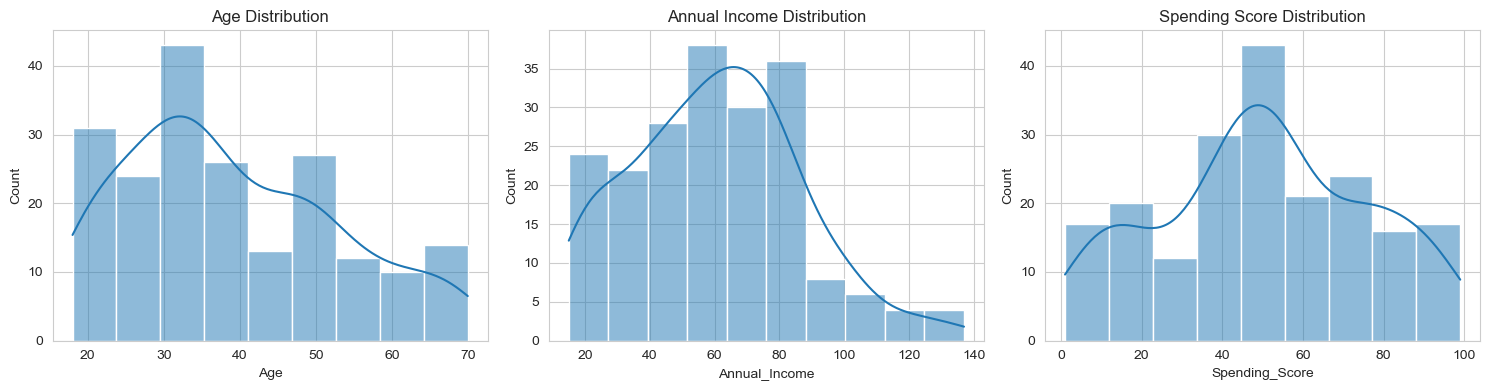

In [2]:
# Feature Distributions

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
sns.histplot(df['Age'], kde=True)
plt.title('Age Distribution')

plt.subplot(1,3,2)
sns.histplot(df['Annual_Income'], kde=True)
plt.title('Annual Income Distribution')

plt.subplot(1,3,3)
sns.histplot(df['Spending_Score'], kde=True)
plt.title('Spending Score Distribution')

plt.tight_layout()
plt.show()

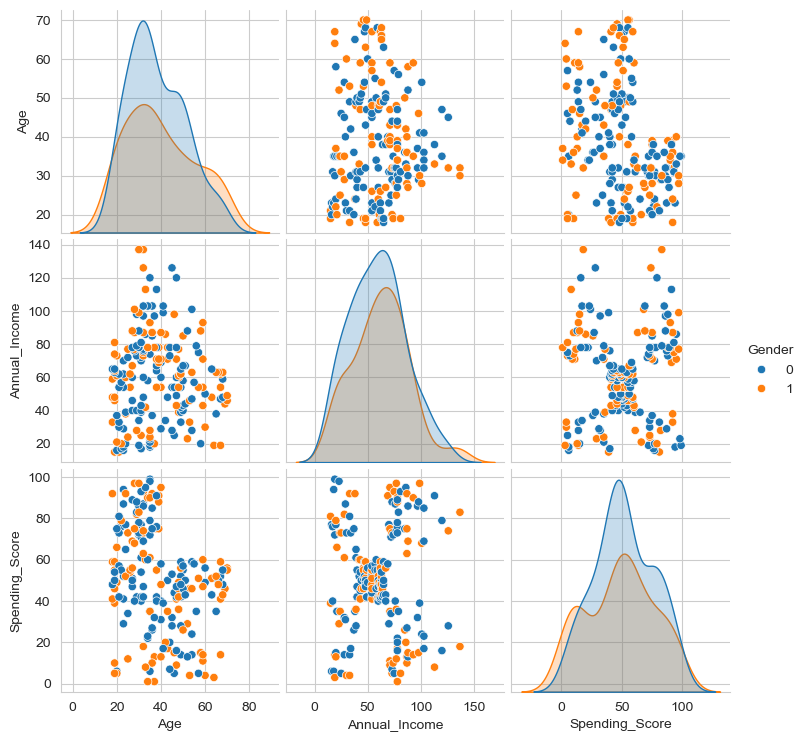

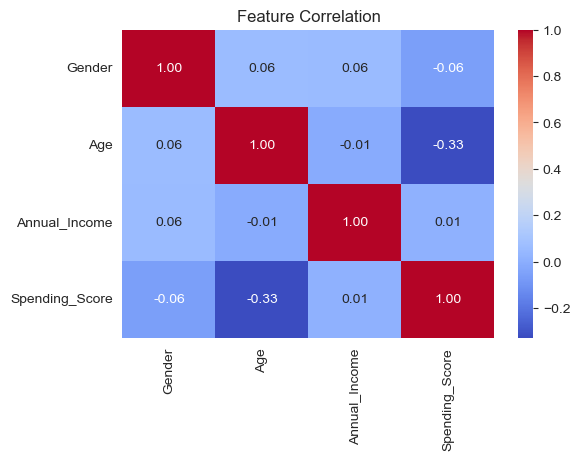

In [3]:
# Pairplot and Correlation Heatmap

sns.pairplot(df, hue='Gender')
plt.show()

plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation')
plt.show()

### Correlation Matrix Observation

- Most variables have **weak linear relationships**, which means each feature gives different information for clustering.

- **Age and Spending Score** show the strongest relationship, with a negative correlation of about **-0.33**. This suggests that older customers generally have slightly lower spending scores, while younger customers may spend more.

- **Annual Income and Spending Score** have almost no linear correlation, around **0.01**. This makes them useful for clustering because they can still form clear visual groups even without a straight-line relationship.

- **Gender has very little effect** on the other variables, as its correlation values are very close to zero. This means gender alone does not strongly explain income, age, or spending behaviour.

## Task 3: K-Means Clustering

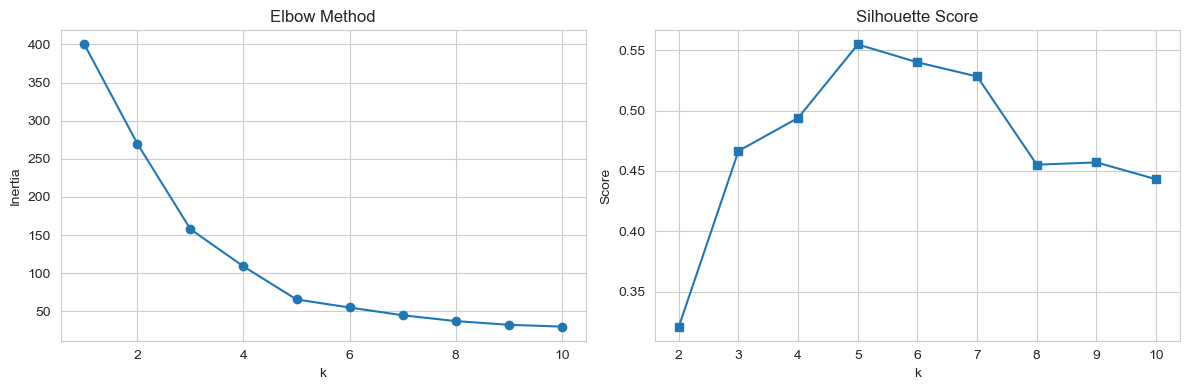

In [4]:
# Elbow Method and Silhouette Score
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia, sil_scores = [], []

for k in range(1,11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(df_2f)
    inertia.append(km.inertia_)
    if k > 1:
        sil_scores.append(silhouette_score(df_2f, km.labels_))

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(range(1,11), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('k')
plt.ylabel('Inertia')

plt.subplot(1,2,2)
plt.plot(range(2,11), sil_scores, marker='s')
plt.title('Silhouette Score')
plt.xlabel('k')
plt.ylabel('Score')

plt.tight_layout()
plt.show()


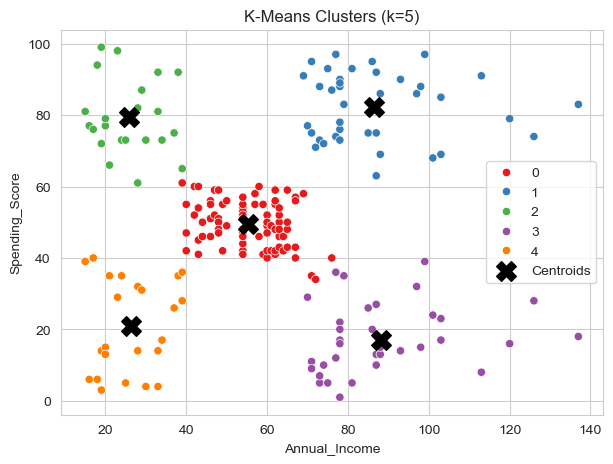

                  Age  Annual_Income  Spending_Score
KMeans_Cluster                                      
0               42.72          55.30           49.52
1               32.69          86.54           82.13
2               25.27          25.73           79.36
3               41.11          88.20           17.11
4               45.22          26.30           20.91


In [5]:
# K-Means Clustering with k=5

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans.fit_predict(df_2f)

centroids = scaler.inverse_transform(
    np.c_[np.zeros(5), kmeans.cluster_centers_]
)[:,1:]

plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='Annual_Income', y='Spending_Score',
                hue='KMeans_Cluster', palette='Set1')
plt.scatter(centroids[:,0], centroids[:,1],
            c='black', marker='X', s=200, label='Centroids')
plt.title('K-Means Clusters (k=5)')
plt.legend()
plt.show()

print(df.groupby('KMeans_Cluster')[['Age','Annual_Income','Spending_Score']].mean().round(2))

## Task 4: Hierarchical Clustering

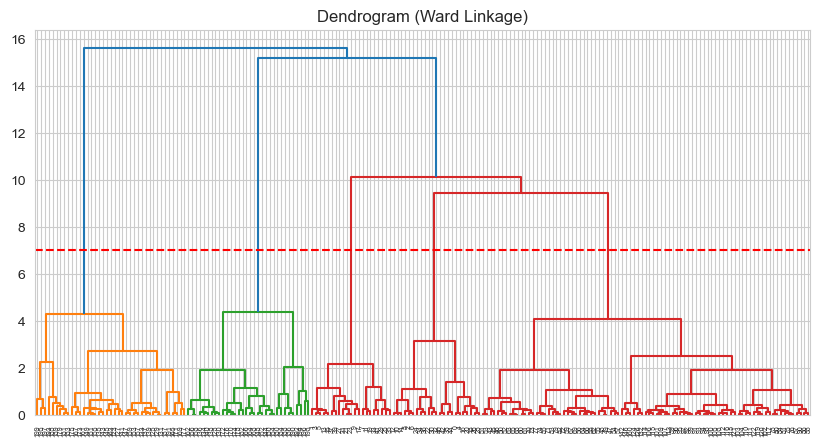

In [6]:
# Hierarchical Clustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

linked = linkage(df_2f, method='ward')

plt.figure(figsize=(10,5))
dendrogram(linked)
plt.axhline(7, color='red', linestyle='--')
plt.title('Dendrogram (Ward Linkage)')
plt.show()



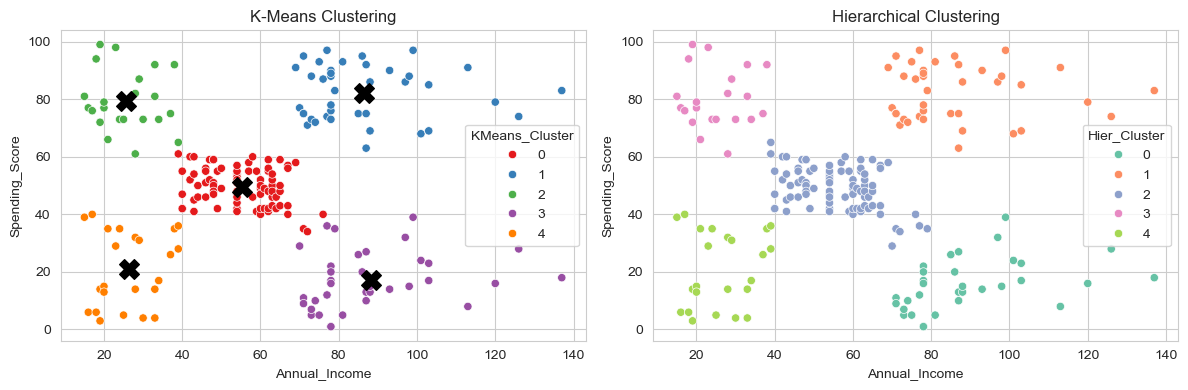

                Age  Annual_Income  Spending_Score
Hier_Cluster                                      
0             41.00          89.41           15.59
1             32.69          86.54           82.13
2             42.48          55.81           49.13
3             25.33          25.10           80.05
4             45.22          26.30           20.91


In [7]:
df['Hier_Cluster'] = AgglomerativeClustering(
    n_clusters=5, linkage='ward'
).fit_predict(df_2f)

fig, ax = plt.subplots(1,2,figsize=(12,4))

sns.scatterplot(data=df, x='Annual_Income', y='Spending_Score',
                hue='KMeans_Cluster', palette='Set1', ax=ax[0])
ax[0].scatter(centroids[:,0], centroids[:,1],
              c='black', marker='X', s=200)
ax[0].set_title('K-Means Clustering')

sns.scatterplot(data=df, x='Annual_Income', y='Spending_Score',
                hue='Hier_Cluster', palette='Set2', ax=ax[1])
ax[1].set_title('Hierarchical Clustering')

plt.tight_layout()
plt.show()

print(df.groupby('Hier_Cluster')[['Age','Annual_Income','Spending_Score']].mean().round(2))

## Task 5: DBSCAN Clustering

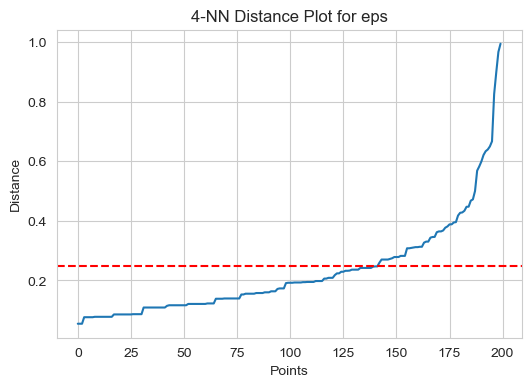

In [8]:
# DBSCAN 4-NN Distance Plot
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

distances = NearestNeighbors(n_neighbors=4).fit(df_2f).kneighbors(df_2f)[0]
distances = np.sort(distances[:,3])

plt.figure(figsize=(6,4))
plt.plot(distances)
plt.axhline(0.25, color='red', linestyle='--')
plt.title('4-NN Distance Plot for eps')
plt.xlabel('Points')
plt.ylabel('Distance')
plt.show()

     eps  min_samples  clusters  noise
0   0.20            3        13     44
1   0.20            4         5     73
2   0.20            5         7     77
3   0.20            6         4     95
4   0.25            3        12     16
5   0.25            4         7     43
6   0.25            5         6     50
7   0.25            6         6     69
8   0.30            3         9     14
9   0.30            4         8     23
10  0.30            5         7     35
11  0.30            6         6     48
12  0.40            3         4     10
13  0.40            4         3     14
14  0.40            5         4     15
15  0.40            6         4     19


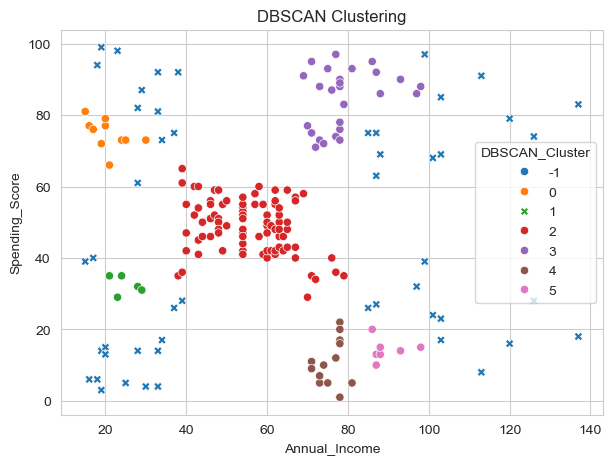

In [9]:
# DBSCAN Grid Search and Final Plot

results = []

for eps in [0.2,0.25,0.3,0.4]:
    for ms in [3,4,5,6]:
        labels = DBSCAN(eps=eps, min_samples=ms).fit_predict(df_2f)
        results.append({
            'eps': eps,
            'min_samples': ms,
            'clusters': len(set(labels)) - (-1 in labels),
            'noise': list(labels).count(-1)
        })

print(pd.DataFrame(results))

df['DBSCAN_Cluster'] = DBSCAN(eps=0.25, min_samples=5).fit_predict(df_2f)

plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='Annual_Income', y='Spending_Score',
                hue='DBSCAN_Cluster',
                style=df['DBSCAN_Cluster'].eq(-1),
                markers={False:'o', True:'X'},
                palette='tab10')
plt.title('DBSCAN Clustering')
plt.show()

### DBSCAN vs K-Means

- **DBSCAN** does not require the number of clusters to be selected before training.
- It can identify low-density or unusual points as **noise**, using the label **-1**.
- **K-Means** assigns every data point to a cluster, even if the point is far away or behaves like an outlier.

## Task 6: Algorithm Comparison & Final Recommendation

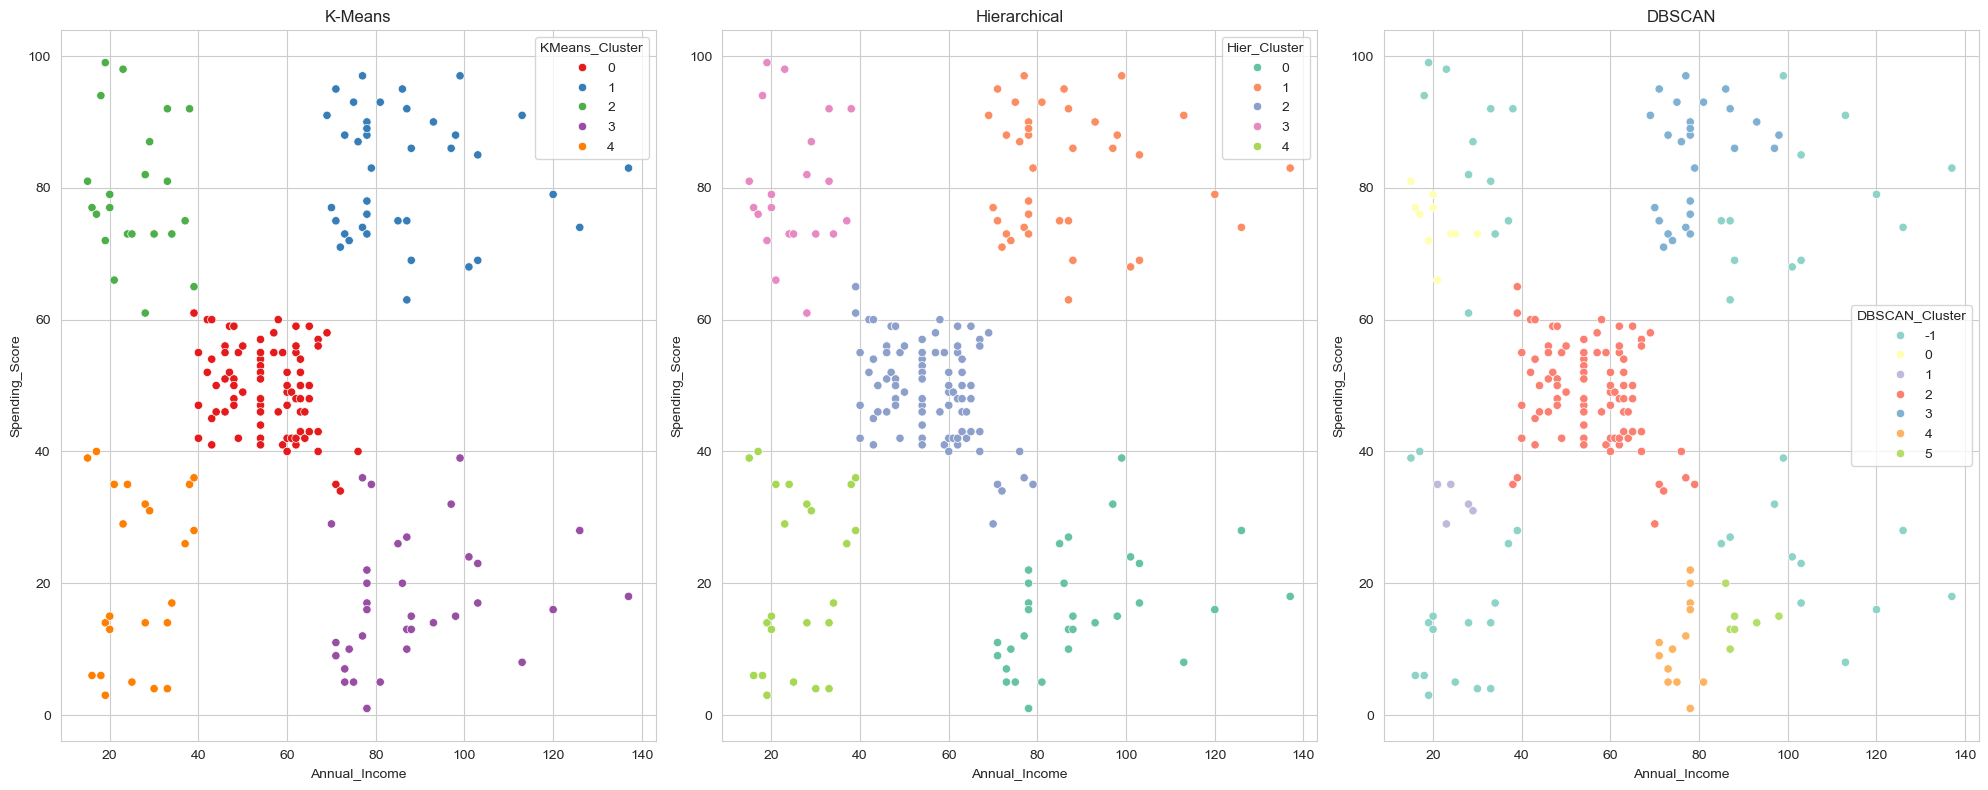

      Algorithm  Clusters  Silhouette Score  Davies-Bouldin  Calinski-Harabasz
0       K-Means         5            0.5547          0.5722           248.6493
1  Hierarchical         5            0.5538          0.5779           244.4103
2        DBSCAN         6            0.5317          0.5580           181.1659


In [10]:
# Visual and Metric Comparison
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

fig, ax = plt.subplots(1,3,figsize=(20,8))

sns.scatterplot(data=df, x='Annual_Income', y='Spending_Score',
                hue='KMeans_Cluster', palette='Set1', ax=ax[0])
ax[0].set_title('K-Means')

sns.scatterplot(data=df, x='Annual_Income', y='Spending_Score',
                hue='Hier_Cluster', palette='Set2', ax=ax[1])
ax[1].set_title('Hierarchical')

sns.scatterplot(data=df, x='Annual_Income', y='Spending_Score',
                hue='DBSCAN_Cluster', palette='Set3', ax=ax[2])
ax[2].set_title('DBSCAN')

plt.tight_layout()
plt.show()

def get_metrics(X, labels, name):
    labels = np.array(labels)
    mask = labels != -1
    return {
        'Algorithm': name,
        'Clusters': len(set(labels[mask])),
        'Silhouette Score': round(silhouette_score(X[mask], labels[mask]), 4),
        'Davies-Bouldin': round(davies_bouldin_score(X[mask], labels[mask]), 4),
        'Calinski-Harabasz': round(calinski_harabasz_score(X[mask], labels[mask]), 4)
    }

metrics = pd.DataFrame([
    get_metrics(df_2f.values, df['KMeans_Cluster'], 'K-Means'),
    get_metrics(df_2f.values, df['Hier_Cluster'], 'Hierarchical'),
    get_metrics(df_2f.values, df['DBSCAN_Cluster'], 'DBSCAN')
])

print(metrics)

### Recommendation

K-Means with **k = 5** is the most suitable clustering method for this dataset. It gives the best overall performance, with a strong **Silhouette Score of 0.5547** and a high **Calinski-Harabasz Score**. It also divides customers into **five clear and practical segments**, making the results easy to understand and useful for marketing decisions.